In [101]:
import meshio as mio
import h5py
import numpy as np
import pyvista as pv
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import scipy as sp
import matplotlib.pyplot as mplt
import json as js
import meshio as mio

# pv.set_jupyter_backend('trame')
pv.set_jupyter_backend('client')



In [65]:
def to_pyvista_mesh(V, F = None):
    if F is None:
        return pv.PolyData(V)
    if F.shape[1] == 3:
        return pv.UnstructuredGrid({pv.CellType.TRIANGLE: F}, V)
    elif F.shape[1] == 4:
        return pv.UnstructuredGrid({pv.CellType.TETRA: F}, V)



In [66]:
# path = "/Users/teseo/Downloads/Embryogram test/new/0in-analysis-07_09T15_10-analysis.hdf5"
path = "/Users/teseo/Downloads/Embryogram test/20250510_tracking-analysis-07_19T18_47-analysis.hdf5"

In [67]:
hdf5_file = h5py.File(path, "r")
V, T = hdf5_file["mesh/v"][:].astype(float), hdf5_file["mesh/t"][:].astype(np.int32)

top = hdf5_file["bc/top"][:].astype(np.int32)
bottom = hdf5_file["bc/bottom"][:].astype(np.int32)
middle = hdf5_file["bc/middle"][:].astype(np.int32)

In [68]:
centers = hdf5_file["bc_func/centers"][:].astype(float)
eps = hdf5_file["bc_func/eps"][()]

In [69]:
nk = len(hdf5_file["bc_func"].keys())-2

disps = []

for i in range(nk):
    disps.append(hdf5_file[f"bc_func/disp{i+1}"][:].astype(float))

In [108]:
E = hdf5_file["problem/E"][()] .astype(float)
nu = hdf5_file["problem/nu"][()] .astype(float)
is_linear = hdf5_file["problem/is_linear"][()] .astype(bool)

# E

In [109]:
# m=to_pyvista_mesh(V, T)
# # m=m.explode(0.5)
# plt = pv.Plotter()
# plt.add_mesh(m, show_edges=True, style='wireframe', line_width=1.0)
# plt.add_mesh(to_pyvista_mesh(V[top]), color='red', point_size=10, render_points_as_spheres=True, name='top')
# plt.add_mesh(to_pyvista_mesh(V[bottom]), color='green', point_size=10, render_points_as_spheres=True, name='bottom')
# plt.add_mesh(to_pyvista_mesh(V[middle]), color='blue', point_size=10, render_points_as_spheres=True, name='middle')
# plt.show()

In [72]:
# m=m.explode(0.5)
plt = pv.Plotter()
plt.add_mesh(to_pyvista_mesh(V[middle]), color='blue', point_size=8, render_points_as_spheres=True, name='middle')
plt.add_mesh(to_pyvista_mesh(centers), color='red', point_size=7, render_points_as_spheres=True, name='middle')
plt.show()

Widget(value='<iframe src="http://localhost:55730/index.html?ui=P_0x3159e5d80_7&reconnect=auto" class="pyvista…

In [73]:
pl = pv.Plotter()
pl.add_mesh(to_pyvista_mesh(centers), color='blue', point_size=3, render_points_as_spheres=True, name='middle')

nd = disps[0].shape[0]
lines = np.hstack([[2, i, nd+i] for i in range(nd)])

vertices = np.vstack([centers, centers + disps[0]])
ll = pv.PolyData(vertices, lines=lines)
pl.add_mesh(ll, name='line')

def callback(x):
    vertices = np.vstack([centers, centers + disps[x]])
    ll = pv.PolyData(vertices, lines=lines)
    pl.add_mesh(ll, name='line')
    pl.update()

pl.show()
interact(callback, x=(0, len(disps)-1, 1))



Widget(value='<iframe src="http://localhost:55730/index.html?ui=P_0x315911f00_8&reconnect=auto" class="pyvista…

interactive(children=(IntSlider(value=119, description='x', max=239), Output()), _dom_classes=('widget-interac…

<function __main__.callback(x)>

In [74]:
import sympy as sp 


t = sp.MatrixSymbol('t', 3, 1)

X = sp.MatrixSymbol('x', 3, 1)
M = sp.MatrixSymbol('M', 3, 3)
PP = sp.MatrixSymbol('P', 3, 3)
K = sp.MatrixSymbol('K', 3, 1)



t1=X*t.T

t2 = M*PP


t3 = M.T * K
t3[0,0]


K[0, 0]*M[0, 0] + K[1, 0]*M[1, 0] + K[2, 0]*M[2, 0]

In [75]:
def align(centers, disps, index):
    p0 = centers.T
    p1 = (centers + disps[index]).T
    one = np.ones((1, p0.shape[1]))

    n = one.shape[1]


    X = p1 @ one.T
    PP = p1 @ p1.T
    K = p1 @ one.T
    
    system = np.zeros((9+3, 9+3))
    rhs = np.zeros((9+3, ))

    rhs[:9] = (p0 @ p1.T).flatten()
    rhs[9:] = (p0 @ one.T).flatten()


    system[0,:3] = PP[:,0]
    system[1,:3] = PP[:,1]
    system[2,:3] = PP[:,2]

    system[3,3:6] = PP[:,0]
    system[4,3:6] = PP[:,1]
    system[5,3:6] = PP[:,2]

    system[6,6:9] = PP[:,0]
    system[7,6:9] = PP[:,1]
    system[8,6:9] = PP[:,2]


    system[0, 9] = X[0,0]
    system[1, 10] = X[0,0]
    system[2, 11] = X[0,0]

    system[0, 9] = X[1,0]
    system[1, 10] = X[1,0]
    system[2, 11] = X[1,0]

    system[0, 9] = X[2,0]
    system[1, 10] = X[2,0]
    system[2, 11] = X[2,0]

    system[9,:3] = K[:,0]
    system[9,3:6] = K[:,0]
    system[9,6:9] = K[:,0]

    system[9, 9] = n
    system[10, 10] = n
    system[11, 11] = n

    sol = np.linalg.solve(system, rhs)

    t = sol[9:12]

    return sol[:9].reshape((3, 3)), np.zeros(3,) #t.reshape((3, ))

M, t = align(centers, disps, 1)

print(M)
print(t)


[[ 1.64746656e+00  1.54429572e-01 -9.12058849e+00]
 [ 4.86199126e-05  1.00012618e+00 -1.28143789e-03]
 [ 1.97527857e-04  4.80221100e-04  9.95000291e-01]]
[0. 0. 0.]


In [76]:
import scipy.optimize as opt


def align_opt(centers, disps, index):
    P = centers.T
    # Q = (centers + disps[index]).T
    Q = P.copy()+ np.array([1, 2, 3]).reshape((3, 1))  # Example adjustment

    E = lambda x: np.sum((P - (x[:9].reshape(3, 3) @ Q + x[9:].reshape((3, 1))))**2)

    M = np.eye(3)
    t = np.zeros(3,)
    x0 = np.concatenate((M.flatten(), t))

    xs=opt.fmin(func=E, x0=x0, disp=True)

    # print(E(x0))
    # print(np.sum(disps[index]**2))

    Ms = xs[:9].reshape((3, 3))
    ts = xs[9:].reshape((3, ))

    return Ms, ts


align_opt(centers, disps, 1)


/var/folders/6g/xhprzp7n4_ncffbpk8r7tpf80000gn/T/ipykernel_41371/2825927263.py:15: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  xs=opt.fmin(func=E, x0=x0, disp=True)


(array([[ 9.96589601e-01, -1.11782443e-02,  2.66215973e-02],
        [-3.62597805e-03,  9.87900880e-01, -2.37030365e-02],
        [ 9.92391067e-04,  1.54842959e-03,  8.08451447e-01]]),
 array([ 0.00607103, -0.00518469,  0.02300387]))

In [77]:
def umeyama(P, Q):
    assert P.shape == Q.shape
    n, dim = P.shape

    centeredP = P - P.mean(axis=0)
    centeredQ = Q - Q.mean(axis=0)

    C = np.dot(np.transpose(centeredP), centeredQ) / n

    V, S, W = np.linalg.svd(C)
    d = (np.linalg.det(V) * np.linalg.det(W)) < 0.0

    if d:
        S[-1] = -S[-1]
        V[:, -1] = -V[:, -1]

    R = np.dot(V, W)

    varP = np.var(P, axis=0).sum()
    c = 1/varP * np.sum(S) # scale factor

    t = Q.mean(axis=0) - P.mean(axis=0).dot(c*R)

    return c, R, t

def align_1(centers, disps, index):
    P = centers.T
    Q = (centers + disps[index]).T
    # Q = P.copy()+ np.array([1, 2, 3]).reshape((3, 1))  # Example adjustment
    # Q = 100*P+ np.array([1, 2, 3]).reshape((3, 1))
    # print(P.shape, Q.shape)
    c, R, t = umeyama(P.T, Q.T)

    # return c, R, t
    return c*R, t

align_1(centers, disps, 1)


(array([[ 1.00054952e+00, -1.46686572e-17,  3.46305304e-18],
        [ 1.39158855e-17,  1.00054952e+00, -1.74231358e-15],
        [ 6.21268614e-18,  1.64497653e-15,  1.00054952e+00]]),
 array([-0.08703205, -0.03777218, -0.00770693]))

In [78]:
def icp(centers, d):
    p0 = centers
    p1 = centers + d
    mu0 = np.mean(p0, axis=0)
    mu1 = np.mean(p1, axis=0)

    p0 -= mu0
    p1 -= mu1
    t = mu0 - mu1

    cov = p1.T @ p0
    U, s, Ut = sp.linalg.svd(cov)
    R = Ut @ U.T

    return R, t

In [79]:
def compute_align_disp(centers, disps, index):
    # M, t = align_opt(centers, disps, index)
    # M, t = align(centers, disps, index)
    # M, t = icp(centers, disps[index])
    M, t = align_1(centers, disps, index)

    tmp = centers + disps[index]
    tmp1 = (M @ tmp.T).T + t

    return tmp1-centers, M, t

compute_align_disp(centers, disps, 1)

(array([[-0.35859461, -0.32743411, -0.35920079],
        [ 0.11299148,  0.2636576 ,  0.50281523],
        [ 0.02368133, -0.11705084,  0.44123355],
        ...,
        [-0.02856402, -0.14598195, -0.09660406],
        [-0.01867998, -0.09861362,  0.12572463],
        [-0.04663517, -0.09405002,  0.10165819]]),
 array([[ 1.00054952e+00, -1.46686572e-17,  3.46305304e-18],
        [ 1.39158855e-17,  1.00054952e+00, -1.74231358e-15],
        [ 6.21268614e-18,  1.64497653e-15,  1.00054952e+00]]),
 array([-0.08703205, -0.03777218, -0.00770693]))

In [80]:
new_disps = []
Ms = []
ts = []
for i in range(len(disps)):
    d, M, t = compute_align_disp(centers, disps, i)
    new_disps.append(d)
    Ms.append(M)
    ts.append(t)

In [81]:
pl = pv.Plotter()
pl.add_mesh(to_pyvista_mesh(centers), color='blue', point_size=3, render_points_as_spheres=True, name='middle')

nd = disps[0].shape[0]
lines = np.hstack([[2, i, nd+i] for i in range(nd)])

vertices = np.vstack([centers, centers + disps[0]])
ll = pv.PolyData(vertices, lines=lines)
pl.add_mesh(ll, name='line', color='red')

vertices = np.vstack([centers, centers + new_disps[0]])
ll = pv.PolyData(vertices, lines=lines)
pl.add_mesh(ll, name='linea', color='green')

def callback(x):
    vertices = np.vstack([centers, centers + disps[x]])
    ll = pv.PolyData(vertices, lines=lines)
    pl.add_mesh(ll, name='line', color='red')

    vertices = np.vstack([centers, centers + new_disps[x]])
    ll = pv.PolyData(vertices, lines=lines)
    pl.add_mesh(ll, name='linea', color='green')
    pl.update()

    print(Ms[x])
    print(ts[x])

pl.show()
interact(callback, x=(0, len(disps)-1, 1), continuous_update=False)





Widget(value='<iframe src="http://localhost:55730/index.html?ui=P_0x315c8c790_9&reconnect=auto" class="pyvista…

interactive(children=(IntSlider(value=119, description='x', max=239), Output()), _dom_classes=('widget-interac…

<function __main__.callback(x)>

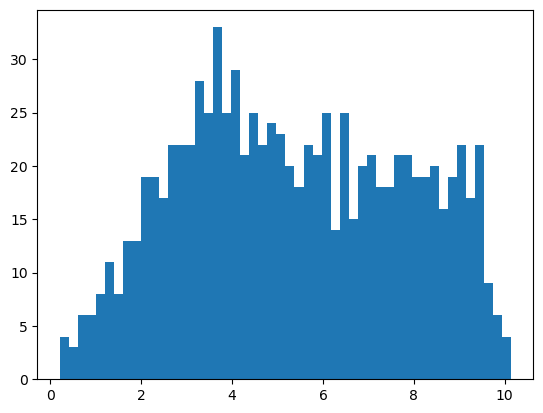

In [82]:
f=206
mplt.hist(np.linalg.norm(np.array(disps[f]-new_disps[f]), axis=1), bins=50)
mplt.show()

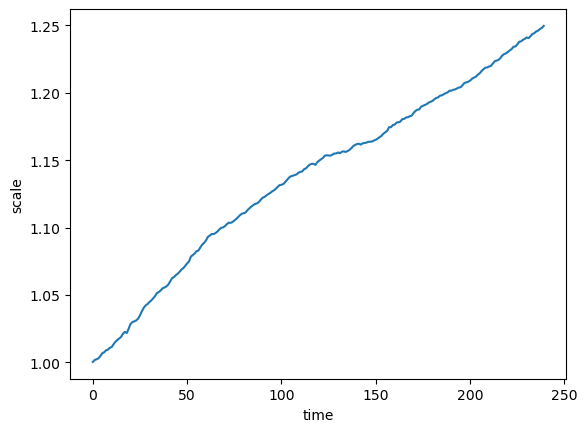

In [83]:
data = [np.linalg.det(M) for M in Ms]
mplt.plot(data)
mplt.xlabel('time')
mplt.ylabel('scale')
mplt.show()

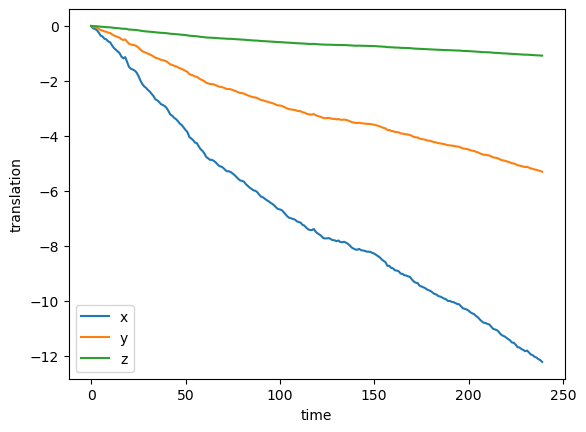

In [84]:
data = [t[0] for t in ts]
mplt.plot(data, label='x')
data = [t[1] for t in ts]
mplt.plot(data, label='y')
data = [t[2] for t in ts]
mplt.plot(data, label='z')
mplt.legend()
mplt.xlabel('time')
mplt.ylabel('translation')
mplt.show()

In [85]:
from scipy.interpolate import RBFInterpolator


In [112]:
default_json = { 
"geometry": {
        "mesh": "___",
        "volume_selection": 1
    },
"boundary_conditions": {
    "dirichlet_boundary": "___"
},
"materials": {
        "E": E,
        "id": 1,
        "nu": nu,
        "type": "LinearElasticity" if is_linear else "NeoHookean"
},
"output": {
    "json": "___",
    "directory": "___",
    "paraview": {
        "file_name": "___",
        "surface": True,
        "options": {
            "material": True,
            "forces": True
        },
        "vismesh_rel_area": 10000000
    }
}
}

In [ ]:
def generate_json(out, V, T, middle, bottom, top, centers, disps, index, eps):
    rbf = RBFInterpolator(centers, disps[index])
    disp = rbf(V[middle,:])

    with open(f"{out}disp_{index}.txt", "w") as f:
        for i in range(middle.shape[0]):
            f.write(f"{middle[i]} {disp[i, 0]} {disp[i, 1]} {disp[i, 2]}\n")
        for i in range(bottom.shape[0]):
            f.write(f"{bottom[i]} 0 0 0\n")
        for i in range(top.shape[0]):
            f.write(f"{top[i]} 0 0 0\n")

    mesh = mio.Mesh(points=V, cells={"tetra": T})
    mesh.write(f"{out}mesh.msh", file_format="gmsh")

    json = default_json.copy()
    json["geometry"]["mesh"] = f"mesh.msh"
    json["boundary_conditions"]["dirichlet_boundary"] = f"disp_{index}.txt"
    json["output"]["directory"] = out
    json["output"]["json"] = f"sim{index}.json"
    json["output"]["paraview"]["file_name"] = f"sim{index}.vtu"

    with open(f"{out}run_{index}.json", "w") as f:
        js.dump(json, f, indent=4)



generate_json("out/", V,T, middle, bottom, top, centers, disps, 0, eps)